In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [ ]:
df = pd.read_csv("spotify-tracks-dataset.csv")

df.head()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0.1      114000 non-null  int64  
 1   Unnamed: 0        114000 non-null  int64  
 2   track_id          114000 non-null  object 
 3   artists           113999 non-null  object 
 4   album_name        113999 non-null  object 
 5   track_name        113999 non-null  object 
 6   popularity        114000 non-null  int64  
 7   duration_ms       114000 non-null  int64  
 8   explicit          114000 non-null  bool   
 9   danceability      114000 non-null  float64
 10  energy            114000 non-null  float64
 11  key               114000 non-null  int64  
 12  loudness          114000 non-null  float64
 13  mode              114000 non-null  int64  
 14  speechiness       114000 non-null  float64
 15  acousticness      114000 non-null  float64
 16  instrumentalness  11

In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 114000
Columns: 22


In [ ]:
df.isnull().sum()

,0
Unnamed: 0.1,0
Unnamed: 0,0
track_id,0
artists,1
album_name,1
track_name,1
popularity,0
duration_ms,0
explicit,0
danceability,0


In [ ]:
df = df.dropna()

df.shape

(113999, 22)

In [ ]:
df = df.drop_duplicates()

df.shape

(113999, 22)

In [ ]:
df.describe()

,Unnamed: 0.1,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,113999.000000,113999.000000,113999.000000,1.139990e+05,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000
mean,56999.421925,56999.421925,33.238827,2.280312e+05,0.566801,0.641383,5.309126,-8.258950,0.637558,0.084652,0.314907,0.156051,0.213554,0.474066,122.147695,3.904034
std,32909.243463,32909.243463,22.304959,1.072961e+05,0.173543,0.251530,3.559999,5.029357,0.480708,0.105733,0.332522,0.309556,0.190378,0.259261,29.978290,0.432623
min,0.000000,0.000000,0.000000,8.586000e+03,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.500000,28499.500000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218500,4.000000
50%,56999.000000,56999.000000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.500000,85499.500000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.597500,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [ ]:
top10 = df.sort_values("popularity", ascending=False)

top10[["track_name", "artists", "popularity"]].head(10)

,track_name,artists,popularity
20001,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,100
81051,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,100
51664,"Quevedo: Bzrp Music Sessions, Vol. 52",Bizarrap;Quevedo,99
88410,La Bachata,Manuel Turizo,98
30003,I'm Good (Blue),David Guetta;Bebe Rexha,98
68303,La Bachata,Manuel Turizo,98
89411,La Bachata,Manuel Turizo,98
81210,I'm Good (Blue),David Guetta;Bebe Rexha,98
67356,La Bachata,Manuel Turizo,98
20008,I'm Good (Blue),David Guetta;Bebe Rexha,98


In [ ]:
top10 = df.sort_values("popularity", ascending=False)

top10[["track_name", "artists", "popularity"]].head(10)

,track_name,artists,popularity
20001,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,100
81051,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,100
51664,"Quevedo: Bzrp Music Sessions, Vol. 52",Bizarrap;Quevedo,99
88410,La Bachata,Manuel Turizo,98
30003,I'm Good (Blue),David Guetta;Bebe Rexha,98
68303,La Bachata,Manuel Turizo,98
89411,La Bachata,Manuel Turizo,98
81210,I'm Good (Blue),David Guetta;Bebe Rexha,98
67356,La Bachata,Manuel Turizo,98
20008,I'm Good (Blue),David Guetta;Bebe Rexha,98


In [ ]:
top_artist = df["artists"].value_counts().head(10)

top_artist


,count
artists,
The Beatles,279
George Jones,271
Stevie Wonder,236
Linkin Park,224
Ella Fitzgerald,222
Prateek Kuhad,217
Feid,202
Chuck Berry,190
Håkan Hellström,183


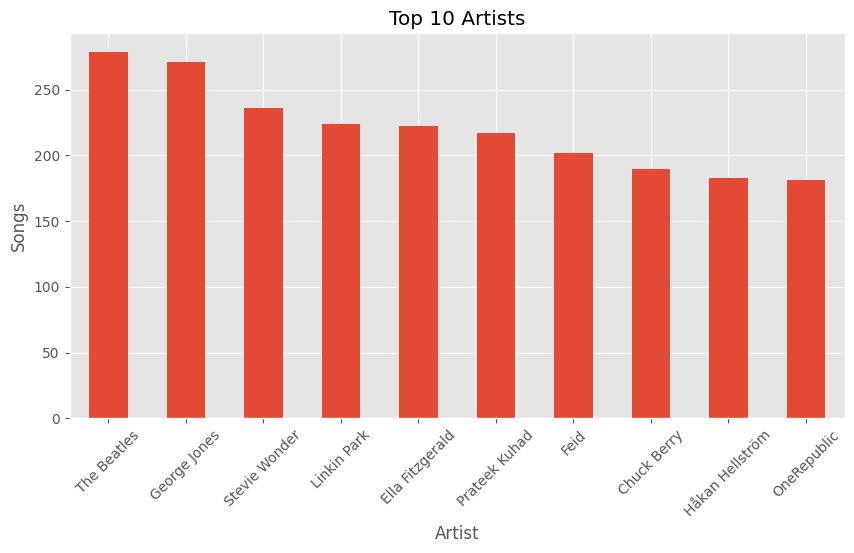

In [ ]:
plt.figure(figsize=(10,5))

top_artist.plot(kind="bar")

plt.title("Top 10 Artists")
plt.xlabel("Artist")
plt.ylabel("Songs")

plt.xticks(rotation=45)

plt.show()

In [ ]:
genre = df["track_genre"].value_counts().head(10)

genre

,count
track_genre,
acoustic,1000
afrobeat,1000
alt-rock,1000
alternative,1000
ambient,1000
anime,1000
black-metal,1000
bluegrass,1000
blues,1000


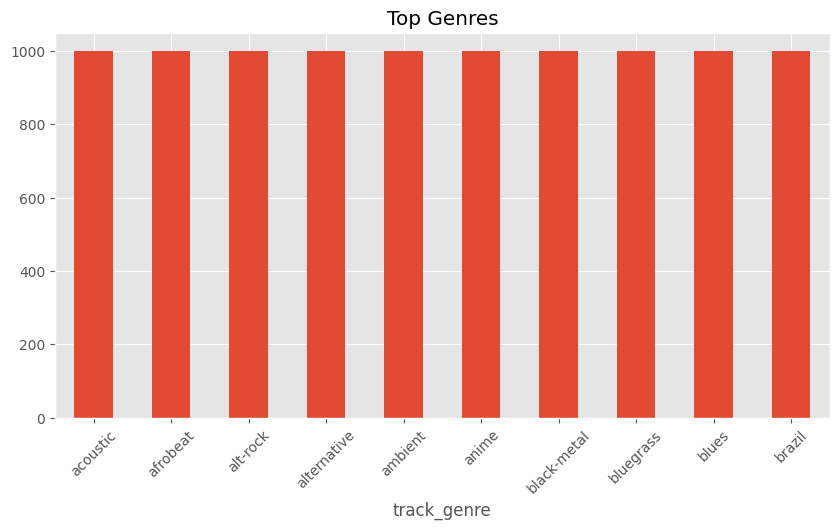

In [ ]:
plt.figure(figsize=(10,5))

genre.plot(kind="bar")

plt.title("Top Genres")

plt.xticks(rotation=45)

plt.show()

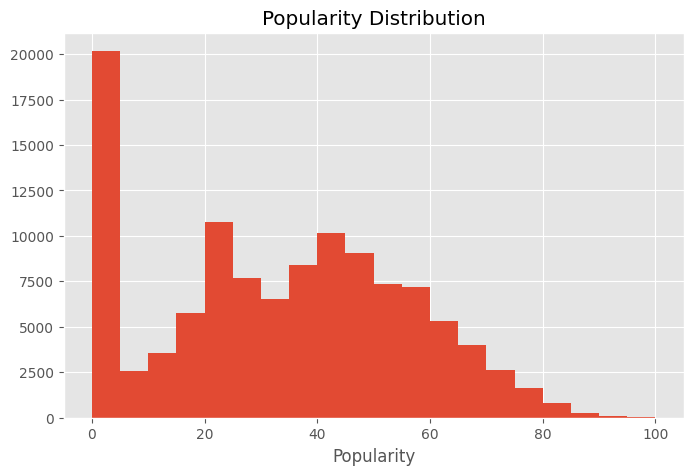

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df["popularity"], bins=20)

plt.title("Popularity Distribution")
plt.xlabel("Popularity")

plt.show()

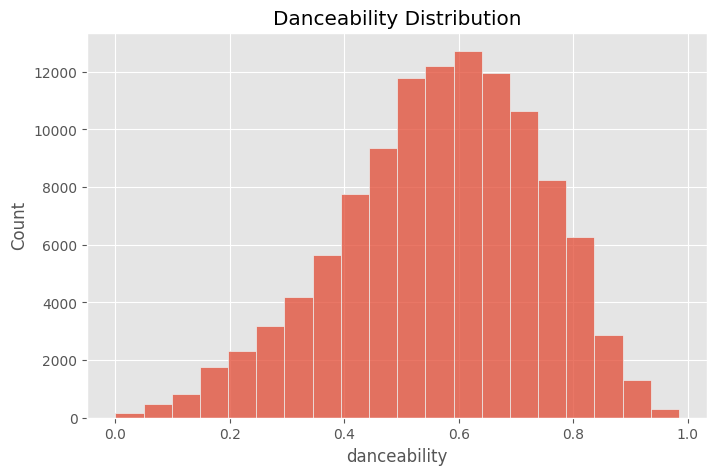

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["danceability"], bins=20)

plt.title("Danceability Distribution")

plt.show()

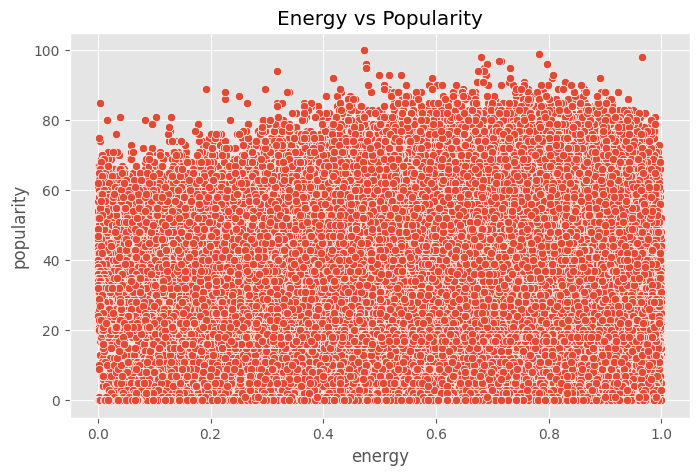

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df,
                x="energy",
                y="popularity")

plt.title("Energy vs Popularity")

plt.show()

In [ ]:
corr = df.corr(numeric_only=True)

corr

,Unnamed: 0.1,Unnamed: 0,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
Unnamed: 0.1,1.000000,1.000000,0.032146,-0.032738,-0.054735,0.003445,-0.055993,-0.005521,-0.027307,0.005110,-0.084952,0.076837,-0.070285,0.033641,0.053109,-0.025825,-0.021115
Unnamed: 0,1.000000,1.000000,0.032146,-0.032738,-0.054735,0.003445,-0.055993,-0.005521,-0.027307,0.005110,-0.084952,0.076837,-0.070285,0.033641,0.053109,-0.025825,-0.021115
popularity,0.032146,0.032146,1.000000,-0.007129,0.044078,0.035444,0.001053,-0.003847,0.050420,-0.013948,-0.044930,-0.025458,-0.095147,-0.005397,-0.040522,0.013212,0.031076
duration_ms,-0.032738,-0.032738,-0.007129,1.000000,-0.065270,-0.073435,0.058520,0.008123,-0.003475,-0.035581,-0.062605,-0.103770,0.124364,0.010308,-0.154464,0.024356,0.018229
explicit,-0.054735,-0.054735,0.044078,-0.065270,1.000000,0.122506,0.096954,0.004485,0.108587,-0.037216,0.307951,-0.094400,-0.103405,0.032547,-0.003378,-0.002815,0.038387
danceability,0.003445,0.003445,0.035444,-0.073435,0.122506,1.000000,0.134325,0.036470,0.259076,-0.069224,0.108625,-0.171531,-0.185608,-0.131620,0.477347,-0.050448,0.207219
energy,-0.055993,-0.055993,0.001053,0.058520,0.096954,0.134325,1.000000,0.048007,0.761690,-0.078365,0.142508,-0.733908,-0.181880,0.184795,0.258937,0.247852,0.187127
key,-0.005521,-0.005521,-0.003847,0.008123,0.004485,0.036470,0.048007,1.000000,0.038591,-0.135911,0.020419,-0.040942,-0.006821,-0.001597,0.034099,0.010914,0.015064
loudness,-0.027307,-0.027307,0.050420,-0.003475,0.108587,0.259076,0.761690,0.038591,1.000000,-0.041768,0.060826,-0.589804,-0.433478,0.076897,0.279851,0.212447,0.191992
mode,0.005110,0.005110,-0.013948,-0.035581,-0.037216,-0.069224,-0.078365,-0.135911,-0.041768,1.000000,-0.046535,0.095568,-0.049961,0.014004,0.021964,0.000572,-0.024090


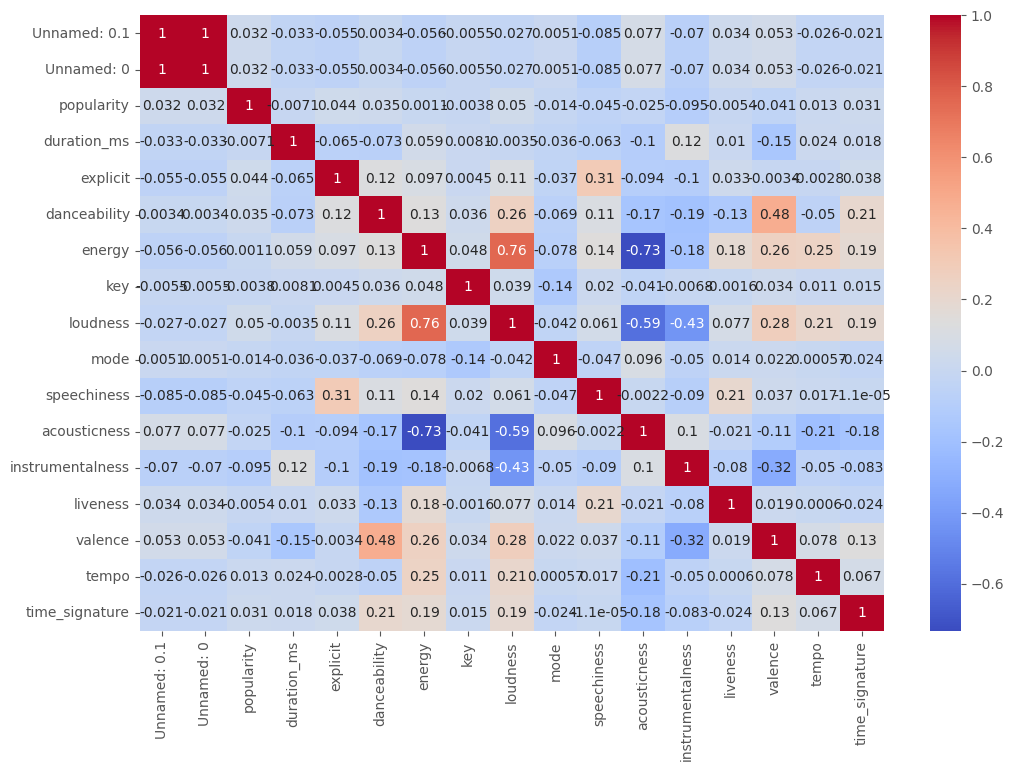

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm")

plt.show()

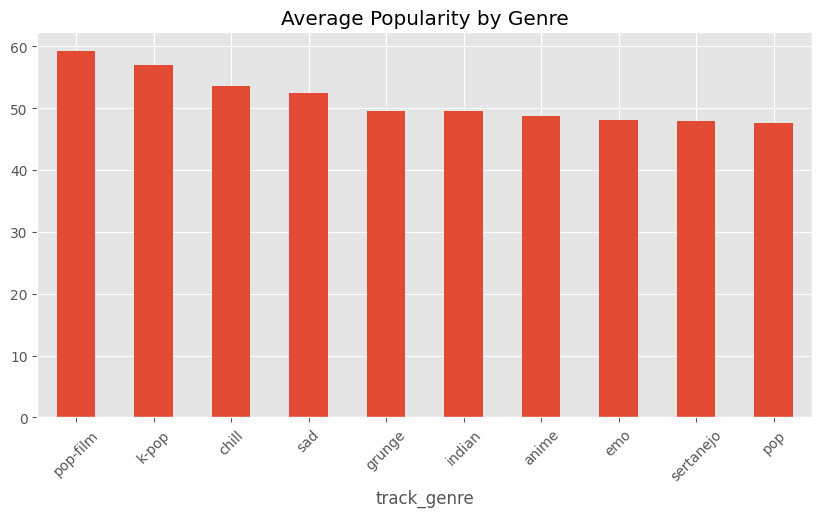

In [ ]:
plt.figure(figsize=(10,5))

avg.plot(kind="bar")

plt.title("Average Popularity by Genre")

plt.xticks(rotation=45)

plt.show()

In [ ]:
print("Spotify Data Analysis Completed Successfully!")

Spotify Data Analysis Completed Successfully!
